In [1]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import Resize, Compose, ToTensor, Normalize
import numpy as np

import math

from torch.utils.tensorboard import SummaryWriter
import datetime

import os, sys
module_path = os.path.abspath(os.path.join('..', "source"))
if module_path not in sys.path:
    sys.path.append(module_path)

import models

from ignite.engine import *

from PIL import Image
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

For now I'm just going to assume that each pbr material has a texture folder and there are three textures named 'arm.jpg', 'albedo.jpg' and 'normal.jpg'.

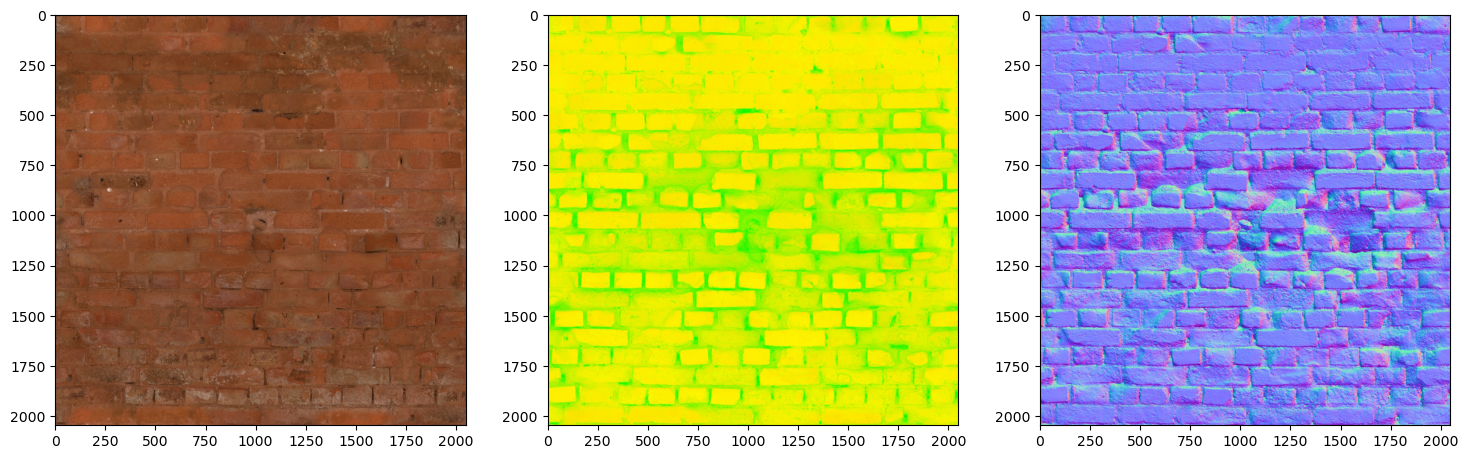

In [2]:
materials_path = "../assets/materials/"
material_name = "broken_brick_wall"
material_textures_path = materials_path + material_name + "/textures/"
ext = ".jpg"

albedo = Image.open(material_textures_path + "albedo" + ext).convert("RGB")
arm = Image.open(material_textures_path + "arm" + ext).convert("RGB")
normal = Image.open(material_textures_path + "normal" + ext).convert("RGB")

fig, axes = plt.subplots(1, 3, figsize=(18,6))
axes[0].imshow(albedo)
axes[1].imshow(arm)
axes[2].imshow(normal)

plt.show()

## Testing Data Conversion/Transform
used for converting from the PBR to a tensor and back

In [3]:
# normalizes values to [0, 1]
def gen_pbr_feature_data(albedo, arm, normal, sidelength):
    transform = Compose([
        Resize(sidelength)
    ])
        
    albedo_data = np.asarray(transform(albedo))
    arm_data = np.asarray(transform(arm))
    normal_data = np.asarray(transform(normal))

    combined = np.concatenate((albedo_data, arm_data, normal_data), axis=2)

    return combined

def extract_images(output, sidelength=None):
    if sidelength is None:
        sidelength = math.sqrt(output.shape[0])
    
    output = np.reshape(output, (sidelength, sidelength, 3 * 3))
    
    albedo_data = output[..., :3]
    arm_data = output[..., 3:6]
    normal_data = output[..., 6:]

    return albedo_data, arm_data, normal_data

(64, 64, 9)


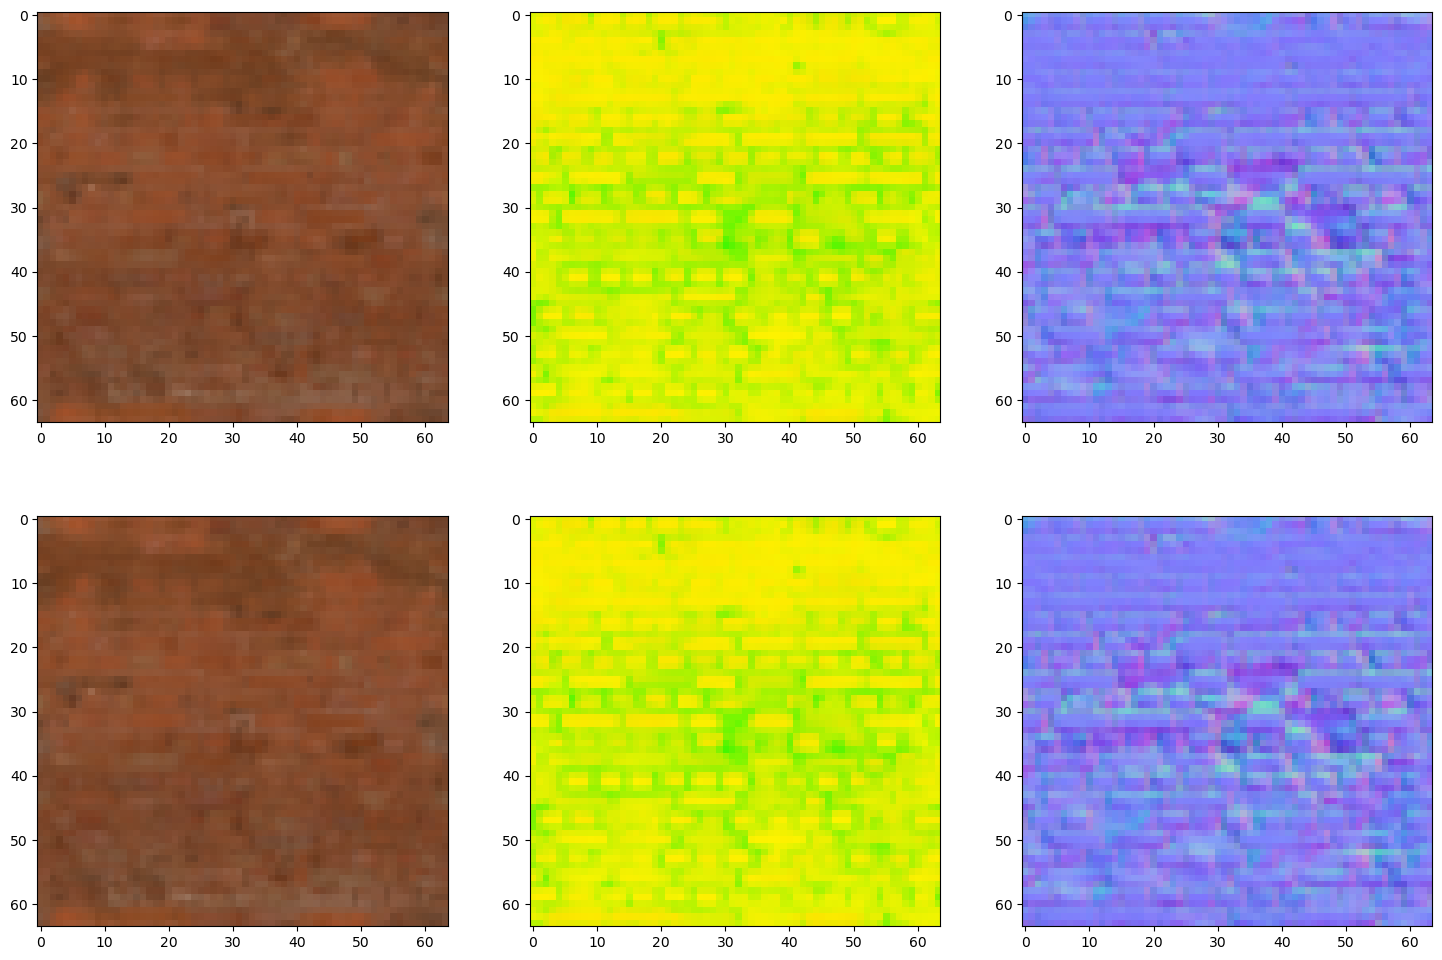

In [19]:
sidelength = 64

transform = Resize(sidelength)

mod_albedo = transform(albedo)
mod_arm = transform(arm)
mod_normal = transform(normal)

output_data = gen_pbr_feature_data(albedo, arm, normal, sidelength)


mod_output_data = np.reshape(output_data, (sidelength * sidelength, 3 * 3))

albedo_data, arm_data, normal_data = extract_images(mod_output_data / 255, sidelength)

print(output_data.shape)

fig, axes = plt.subplots(2, 3, figsize=(18,12))
axes[0, 0].imshow(mod_albedo)
axes[0, 1].imshow(mod_arm)
axes[0, 2].imshow(mod_normal)
axes[1, 0].imshow(albedo_data)
axes[1, 1].imshow(arm_data)
axes[1, 2].imshow(normal_data)

plt.show()

In [22]:
idx = 164
x_idx = idx % sidelength
y_idx = math.trunc(idx / sidelength)

print(mod_albedo.getpixel((x_idx, y_idx)), mod_arm.getpixel((x_idx, y_idx)), mod_normal.getpixel((x_idx, y_idx)))
print(output_data[y_idx][x_idx])
print(mod_output_data[idx])

(119, 74, 49) (231, 242, 0) (97, 156, 241)
[119  74  49 231 242   0  97 156 241]
[119  74  49 231 242   0  97 156 241]


## Dataset

In [3]:
def get_mgrid(sidelen, dim=2):
    '''Generates a flattened grid of (x,y,...) coordinates in a range of -1 to 1.
    sidelen: int
    dim: int'''
    tensors = tuple(dim * [torch.linspace(-1, 1, steps=sidelen)])
    mgrid = torch.stack(torch.meshgrid(*tensors), dim=-1)
    mgrid = mgrid.reshape(-1, dim)
    return mgrid

class PBRDataset(Dataset):
    def __init__(self, albedo_img, arm_img, normal_img, sidelength):
        super().__init__()

        self.sidelength = sidelength
        self.size = sidelength * sidelength

        transform = Resize(self.sidelength)
        
        self.albedo_img = transform(albedo_img)
        self.arm_img = transform(arm_img)
        self.normal_img = transform(normal_img)

        albedo_data = np.asarray(transform(albedo_img))
        arm_data = np.asarray(transform(arm_img))
        normal_data = np.asarray(transform(normal_img))

        combined = np.concatenate((albedo_data, arm_data, normal_data), axis=2)
        combined = np.reshape(combined, (sidelength * sidelength, 3 * 3))
        combined = combined / 255
        
        self.output_features_tensor = torch.from_numpy(combined).cuda()
        self.input_features_tensor = get_mgrid(sidelength).cuda()

    def __len__(self):
        return self.size

    def __getitem__(self, idx):
        if idx > self.size or idx < 0: raise IndexError

        return self.input_features_tensor[idx], self.output_features_tensor[idx]


# Testing Dataset

C:\Users\avree\miniforge3\envs\ml\lib\site-packages\torch\functional.py:554: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\bld\libtorch_1753839109265\work\aten\src\ATen\native\TensorShape.cpp:4316.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


torch.Size([262144, 2])
torch.Size([262144, 9])


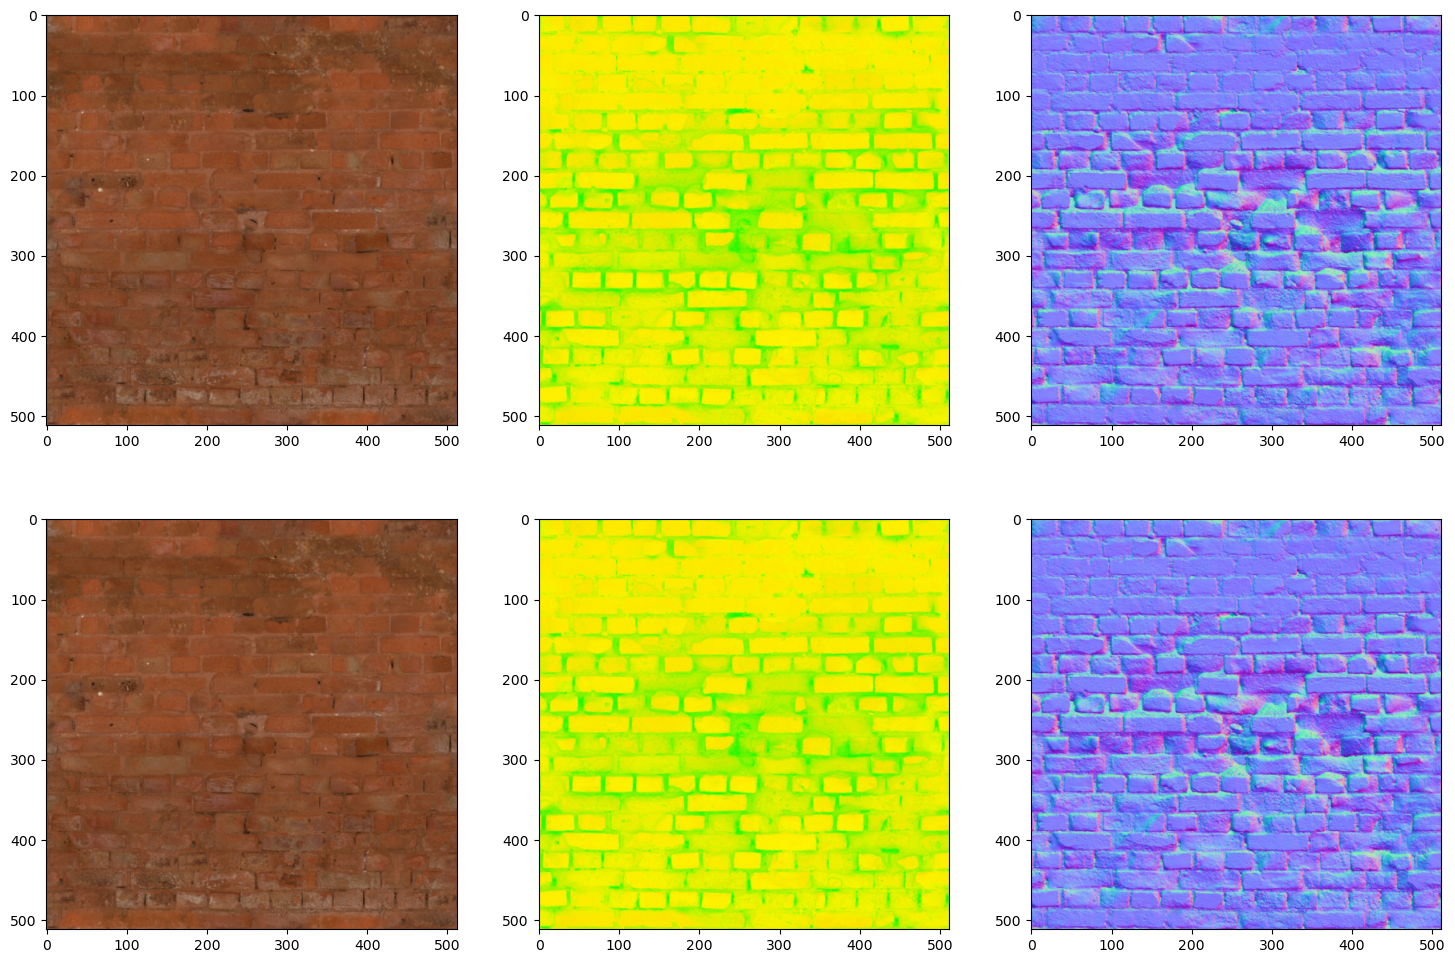

In [5]:
sidelength = 512

transform = Resize(sidelength)

mod_albedo = transform(albedo)
mod_arm = transform(arm)
mod_normal = transform(normal)

dataset = PBRDataset(albedo, arm, normal, sidelength)

output = dataset.output_features_tensor.cpu().view((sidelength, sidelength, -1))

albedo_data = output[..., :3]
arm_data = output[..., 3:6]
normal_data = output[..., 6:]

print(dataset.input_features_tensor.shape)
print(dataset.output_features_tensor.shape)

fig, axes = plt.subplots(2, 3, figsize=(18,12))
axes[0, 0].imshow(mod_albedo)
axes[0, 1].imshow(mod_arm)
axes[0, 2].imshow(mod_normal)
axes[1, 0].imshow(albedo_data)
axes[1, 1].imshow(arm_data)
axes[1, 2].imshow(normal_data)

plt.show()

# Metrics

In [7]:
def psnr(y_pred, y, data_range):
    dim = tuple(range(1, y.ndim))
    mse_error = torch.pow(y_pred - y.view_as(y_pred), 2).mean(dim=dim)
    val = torch.sum(10.0 * torch.log10(data_range**2 / (mse_error + 1e-10))).cpu().item()

    val = val / y.shape[0]
    
    return val

# Training Loop

In [30]:
def test_model(model, dataset, loss_fn, albedo_data, arm_data, normal_data):
    model.eval()

    with torch.no_grad():
        test_pred = model(dataset.input_features_tensor)
        test_loss = loss_fn(test_pred, dataset.output_features_tensor)

    test_pred_features = test_pred.cpu().view((dataset.sidelength, dataset.sidelength, -1)).detach()
    
    albedo_pred_raw = test_pred_features[..., :3]
    arm_pred_raw = test_pred_features[..., 3:6]
    normal_pred_raw = test_pred_features[..., 6:]        
    
    albedo_pred = np.clip(albedo_pred_raw.numpy(), 0.0, 1.0)
    arm_pred = np.clip(arm_pred_raw.numpy(), 0.0, 1.0)
    normal_pred = np.clip(normal_pred_raw.numpy(), 0.0, 1.0)
        
    fig, axes = plt.subplots(2, 3, figsize=(18,12))
    axes[0, 0].imshow(albedo_data)
    axes[0, 1].imshow(arm_data)
    axes[0, 2].imshow(normal_data)
    axes[1, 0].imshow(albedo_pred)
    axes[1, 1].imshow(arm_pred)
    axes[1, 2].imshow(normal_pred)

    plt.show()

    return albedo_pred_raw, arm_pred_raw, normal_pred_raw

def output_test_data(model, albedo_pred, arm_pred, normal_pred, albedo_data, arm_data, normal_data, current_epoch_arg):
    writer.add_scalar('psnr/albedo', psnr(albedo_pred, albedo_data, 1.0), current_epoch_arg)
    writer.add_scalar('psnr/arm', psnr(arm_pred, arm_data, 1.0), current_epoch_arg)
    writer.add_scalar('psnr/normal', psnr(normal_pred, normal_data, 1.0), current_epoch_arg)

    albedo_image = np.clip(albedo_pred.numpy(), 0.0, 1.0)
    arm_image = np.clip(arm_pred.numpy(), 0.0, 1.0)
    normal_image = np.clip(normal_pred.numpy(), 0.0, 1.0)
    
    writer.add_image('image/albedo', albedo_image, current_epoch_arg, dataformats='HWC')
    writer.flush()
    writer.add_image('image/arm', arm_image, current_epoch_arg, dataformats='HWC')
    writer.flush()
    writer.add_image('image/normal', normal_image, current_epoch_arg, dataformats='HWC')
    writer.flush()

    print(current_epoch_arg, " Working")

    for i, layer in enumerate(model.net):
        writer.add_histogram(f"layer{i}/weights", layer.linear.weight, current_epoch_arg)
        writer.add_histogram(f"layer{i}/biases", layer.linear.bias, current_epoch_arg)

def training_loop(model, optimizer, dataloader, loss_fn, num_epochs, summary_interval):
    dataset = dataloader.dataset
    
    data_size = len(dataset)

    output_features = dataset.output_features_tensor.cpu().view((dataset.sidelength, dataset.sidelength, -1)).detach()

    albedo_data = output_features[..., :3]
    arm_data = output_features[..., 3:6]
    normal_data = output_features[..., 6:]
    
    for epoch_idx in range(num_epochs):        
        current_epoch_loc = current_epoch + epoch_idx
        
        clear_output(wait=True)
        
        albedo_pred, arm_pred, normal_pred = test_model(model, dataset, loss_fn, albedo_data, arm_data, normal_data)

        if epoch_idx != 0 or current_epoch_loc == 0:
            output_test_data(model, albedo_pred, arm_pred, normal_pred, albedo_data, arm_data, normal_data, current_epoch_loc)

        print(f"epoch: {current_epoch_loc:>3d}")
        
        model.train()
        for batch_idx, (input_tensor, ground_truth) in enumerate(dataloader):
            pred = model(input_tensor)
            loss = loss_fn(pred, ground_truth)

            writer.add_scalar('loss', loss.item(), batch_idx + len(dataloader) * (current_epoch_loc))
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            if batch_idx % summary_interval == 0:
                print(f"loss: {loss.item():>7f} [{(batch_idx * dataloader.batch_size + len(input_tensor)):>5d}/{data_size:>5d}]")

        writer.flush()

    clear_output(wait=True)

    albedo_pred, arm_pred, normal_pred = test_model(model, dataset, loss_fn, albedo_data, arm_data, normal_data)
    output_test_data(model, albedo_pred, arm_pred, normal_pred, albedo_data, arm_data, normal_data, current_epoch + num_epochs)

    print(f"epoch: {(current_epoch + num_epochs):>3d}")

In [25]:
if 'writer' in globals():
    writer.close()
    del writer
    
writer = SummaryWriter("../experiments/pbr_compression/siren" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))

model = models.Siren(in_features=2, out_features=3*3, hidden_features=64, hidden_layers=3).cuda()

dataset = PBRDataset(albedo, arm, normal, sidelength=128)
dataloader = DataLoader(dataset, batch_size=128, shuffle=True)

writer.add_graph(model.net, dataset.input_features_tensor)

current_epoch = 0

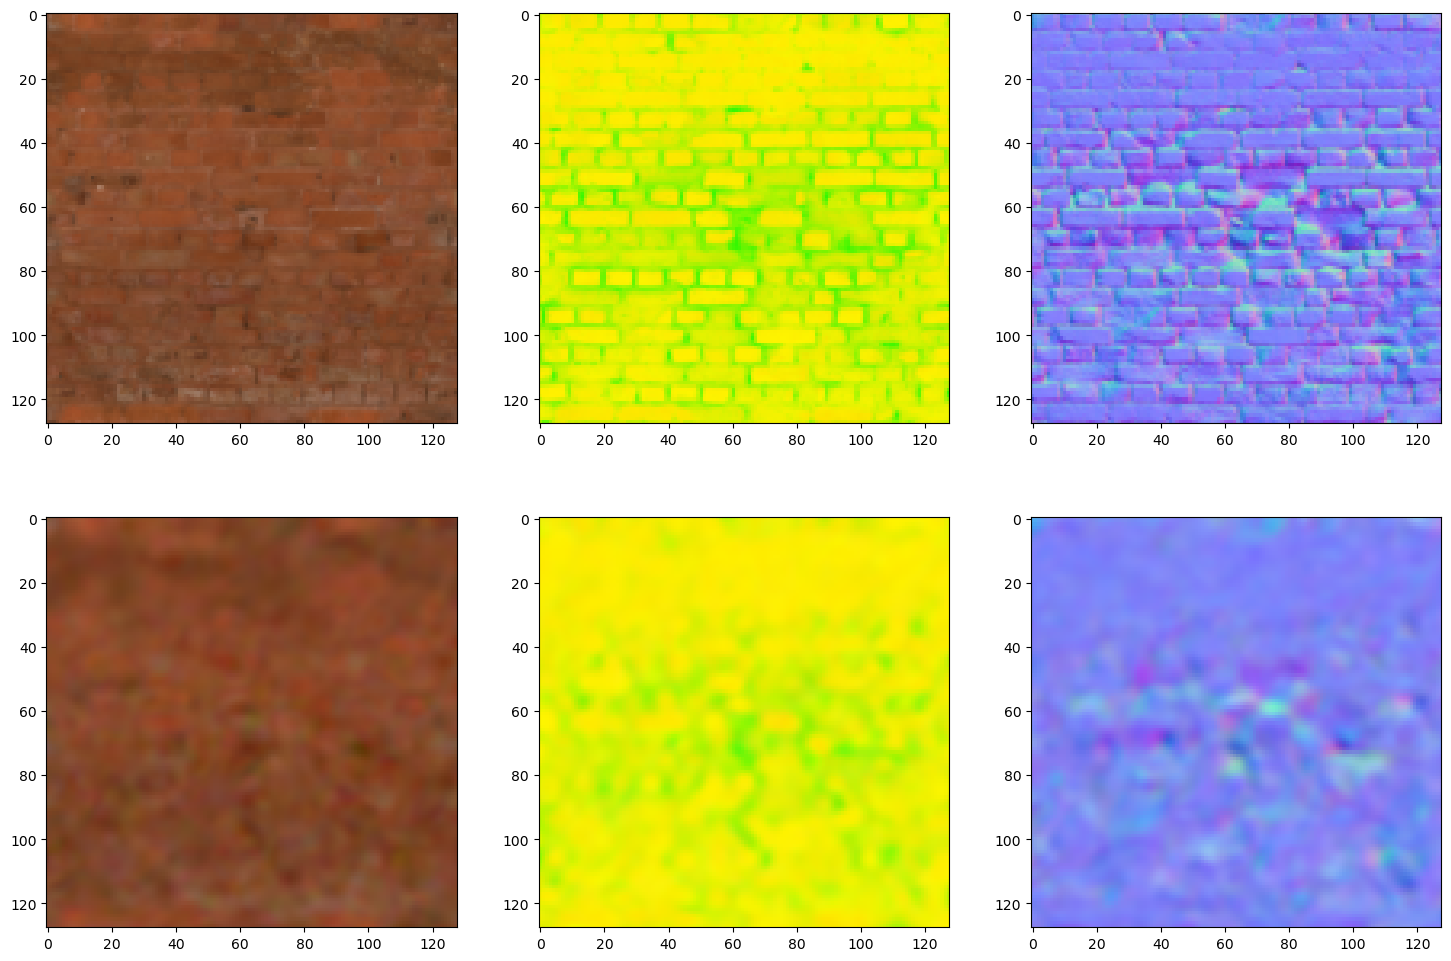

20  Working
epoch:  20


In [31]:
optimizer = torch.optim.Adam(lr=1e-4, params=model.parameters())

loss_fn = torch.nn.L1Loss()

num_epochs = 10

training_loop(model, optimizer, dataloader, loss_fn, num_epochs, 20)
current_epoch = current_epoch + num_epochs